# Montagem do Google Drive

In [ ]:
import os
from google.colab import drive
if not os.path.ismount('/content/drive'):
    print("Montando o Google Drive...")
    drive.mount('/content/drive')

Montando o Google Drive...
Mounted at /content/drive


# Download de algumas imagens do COCO Dataset

In [ ]:
import os
import urllib.request
import zipfile

# Criar pasta para os dados
os.makedirs('coco_minimal', exist_ok=True)

# URL das 10 imagens de validação (já pré-selecionadas)
image_urls = [
    "http://images.cocodataset.org/val2017/000000039769.jpg",  # gato
    "http://images.cocodataset.org/val2017/000000037777.jpg",  # gato
    "http://images.cocodataset.org/val2017/000000252219.jpg" # cachorro

]

# Baixar as imagens
for i, url in enumerate(image_urls):
    filename = f"coco_minimal/image_{i+1:03d}.jpg"
    print(f"Baixando {filename}...")
    urllib.request.urlretrieve(url, filename)

print("✅ Todas as 10 imagens baixadas!")

Baixando coco_minimal/image_001.jpg...
Baixando coco_minimal/image_002.jpg...
Baixando coco_minimal/image_003.jpg...
✅ Todas as 10 imagens baixadas!


# Carregar Modelo Pré-Treinado SSD com MobileNetV2

In [ ]:
import tensorflow_hub as hub
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Carregar modelo SSD MobileNetV2 do TensorFlow Hub
model_url = "https://tfhub.dev/tensorflow/ssd_mobilenet_v2/2"
detector = hub.load(model_url)

print("✅ Modelo carregado com sucesso!")

✅ Modelo carregado com sucesso!


# Labels das classes

In [ ]:
coco_labels = [
    "background", "person", "bicycle", "car", "motorcycle",
    "airplane", "bus", "train", "truck", "boat",
    "traffic light", "fire hydrant", "unknown", "stop sign", "parking meter",
    "bench", "bird", "cat", "dog", "horse",
    "sheep", "cow", "elephant", "bear", "zebra",
    "giraffe", "unknown", "backpack", "umbrella", "unknown",
    "unknown", "handbag", "tie", "suitcase", "frisbee",
    "skis", "snowboard", "sports ball", "kite", "baseball bat",
    "baseball glove", "skateboard", "surfboard", "tennis racket", "bottle",
    "unknown", "wine glass", "cup", "fork", "knife",
    "spoon", "bowl", "banana", "apple", "sandwich",
    "orange", "broccoli", "carrot", "hot dog", "pizza",
    "donut", "cake", "chair", "couch", "potted plant",
    "bed", "unknown", "dining table", "unknown", "unknown",
    "toilet", "unknown", "tv", "laptop", "mouse",
    "remote", "keyboard", "cell phone", "microwave", "oven",
    "toaster", "sink", "refrigerator", "unknown", "book",
    "clock", "vase", "scissors", "teddy bear", "hair drier",
    "toothbrush"
]


Total de classes: 91


# Função para Detectar Objetos em uma Imagem

In [ ]:
def detect_objects(image_path, threshold=0.5):
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    input_tensor = tf.convert_to_tensor(image_rgb)
    input_tensor = input_tensor[tf.newaxis, ...]

    detections = detector(input_tensor)

    boxes = detections['detection_boxes'][0].numpy()
    classes = detections['detection_classes'][0].numpy().astype(int)
    scores = detections['detection_scores'][0].numpy()

    print("🔍 Classes detectadas (brutas):", np.unique(classes))

    mask = scores > threshold
    boxes = boxes[mask]
    classes = classes[mask]
    scores = scores[mask]

    # Remover classes fora do intervalo válido (1-90)
    valid_mask = (classes >= 1) & (classes <= 90)
    boxes = boxes[valid_mask]
    classes = classes[valid_mask]
    scores = scores[valid_mask]

    return boxes, classes, scores, image_rgb

# Função para Visualizar Resultados

In [ ]:
def plot_detections(image, boxes, classes, scores, labels, threshold=0.5):
    plt.figure(figsize=(12, 8))
    plt.imshow(image)
    ax = plt.gca()

    for box, cls, score in zip(boxes, classes, scores):
        if score < threshold:
            continue

        # Validação final: garante que cls está entre 1 e 90
        if cls < 1 or cls > len(labels):
            print(f"⚠️ Classe inválida ignorada: {cls}")
            continue

        ymin, xmin, ymax, xmax = box
        h, w = image.shape[:2]
        left = int(xmin * w)
        top = int(ymin * h)
        right = int(xmax * w)
        bottom = int(ymax * h)

        rect = plt.Rectangle((left, top), right - left, bottom - top,
                             linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)

        label_name = labels[cls - 1]  # cls=1 → índice 0, cls=90 → índice 89
        plt.text(left, top - 10, f"{label_name}: {score:.2f}",
                 color='red', fontsize=12, weight='bold',
                 bbox=dict(facecolor='white', alpha=0.7))

    plt.axis('off')
    plt.title("Detecção de Objetos com SSD-MobileNetV2")
    plt.show()

# Realizar a detecção

Processando: coco_minimal/image_001.jpg
🔍 Classes detectadas (brutas): [ 1  3 16 17 18 23 32 33 44 48 49 50 51 52 53 55 62 63 65 67 73 74 75 77
 84 85 86 87 88 90]


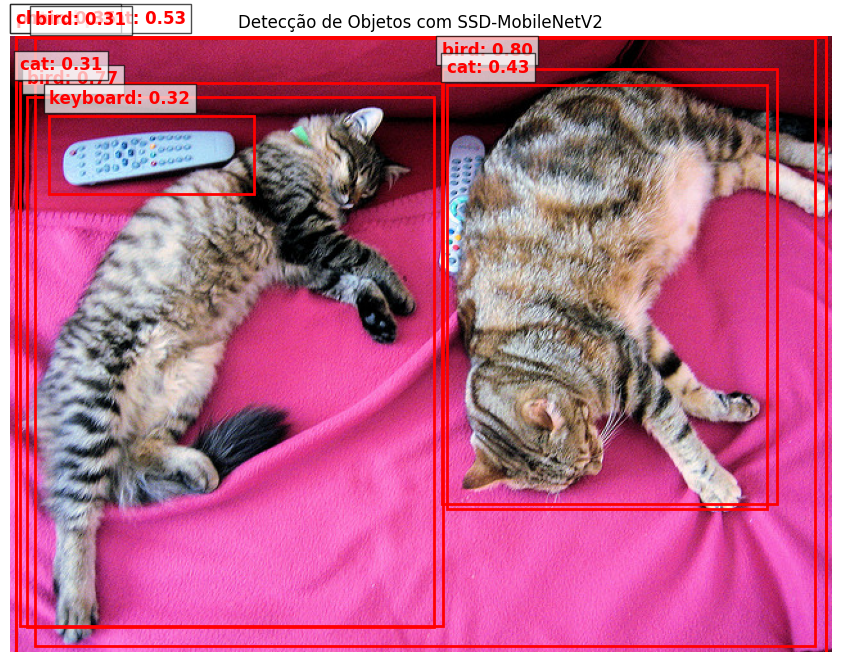

In [ ]:
# Escolher uma imagem
image_files = sorted([f for f in os.listdir('coco_minimal') if f.endswith('.jpg')])
sample_image = os.path.join('coco_minimal', image_files[0])  # Primeira imagem

print(f"Processando: {sample_image}")

# Detectar
boxes, classes, scores, image_rgb = detect_objects(sample_image, threshold=0.3)

# Mostrar resultado
plot_detections(image_rgb, boxes, classes, scores, coco_labels, threshold=0.3)